# GRU

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Data analysis

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
# data.head()

In [4]:
# data.describe()

In [5]:
# # The number of missing values 
# data.isna().sum()

## Data processing

In [6]:
# Define window size and target column
window_size = 15
target_col = "close"
target_col_idx = data.columns.get_loc(target_col)

In [7]:
# Train-val split (80% training, 20% validation)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
val_data = data.iloc[split_index:] 

print(train_data.shape)
print(val_data.shape)

(47074, 4)
(11769, 4)


In [8]:
# Fit scaler on training data only and transform both datasets
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

In [9]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [10]:
# Create sequences for training and validation
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(47059, 15, 4) (47059,)
(11754, 15, 4) (11754,)


## GRU

In [11]:
# Define GRU model
gru_model = Sequential([
    GRU(60, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(1)  # Predicting the close price
])
gru_model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60)             │        11,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,941 (46.64 KB)

 Trainable params: 11,941 (46.64 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0263 - val_loss: 4.1585e-04
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 8.9023e-05
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 9.7007e-05
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0010 - val_loss: 1.4079e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.3619e-04 - val_loss: 7.6628e-05
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.6965e-04 - val_loss: 2.0860e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1877e-04 - val_loss: 0.0010
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7735e-04 - val_loss: 6.4449e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.2688e-04 - val_loss: 7.7482e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.4596e-04 - val_loss: 8.7068e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.3688e-04 - val_l

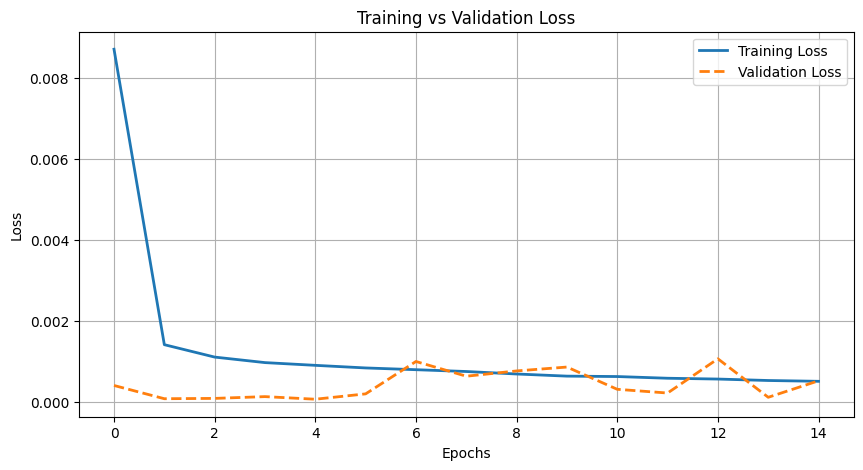

In [13]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation 

In [14]:
# Make predictions
predicted_scaled = gru_model.predict(X_val)

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step


In [15]:
# Prepare arrays for inverse transformation:
# Since the scaler was fitted on all features, need to create an array of the same shape, and only fill in the target column.
predicted_full = np.zeros((predicted_scaled.shape[0], data.shape[1]))
y_val_full = np.zeros((y_val.shape[0], data.shape[1]))

predicted_full[:, target_col_idx] = predicted_scaled[:, 0]
y_val_full[:, target_col_idx] = y_val

In [16]:
# Inverse transform using the scaler fitted on the training data
predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
y_val_inverse = scaler.inverse_transform(y_val_full)[:, target_col_idx]

# Compute error metrics
mae = mean_absolute_error(y_val_inverse, predicted_inverse)
rmse = sqrt(mean_squared_error(y_val_inverse, predicted_inverse))
mape = np.mean(np.abs((y_val_inverse - predicted_inverse) / y_val_inverse)) * 100  

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 368.1798
Root Mean Squared Error (RMSE): 573.2570
Mean Absolute Percentage Error (MAPE): 0.54%


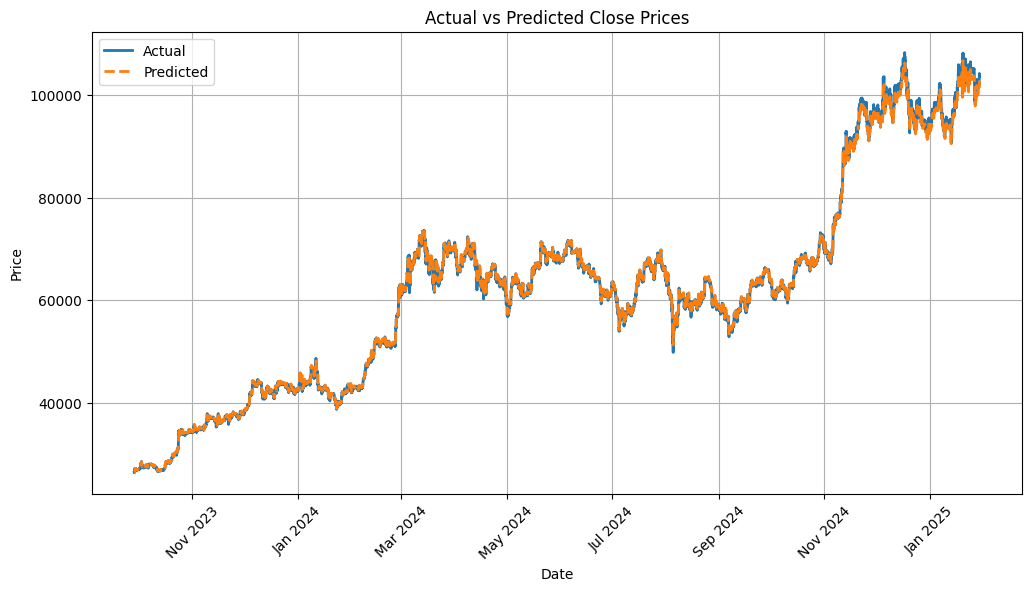

In [17]:
# Extract date index for plotting
# Note: val_data.index includes extra rows for sequence creation; we align using window_size offset.
date_index = val_data.index[window_size:]

# Plot actual vs predicted close prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual', linewidth=2)
plt.plot(date_index, predicted_inverse, label='Predicted', linewidth=2, linestyle='dashed')
plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()